In [7]:
import pandas as pd
df = pd.read_csv('df_ml_TP (1).csv')

In [8]:
df.columns

Index(['target', 'ddd', 'hora_contato', 'dia_semana', 'hora_ultimo_contato',
       'densidade_tentativas', 'pressao_recente'],
      dtype='object')

In [9]:
df.head()

,target,ddd,hora_contato,dia_semana,hora_ultimo_contato,densidade_tentativas,pressao_recente
0,0,13,15,3,-1.0,0.0000,0.0000
1,0,13,15,3,15.0,0.9203,0.9203
2,0,13,12,4,15.0,0.0938,0.0942
3,0,13,17,4,12.0,0.1125,0.4732
4,0,13,17,4,17.0,0.1496,3.6814


In [10]:
len(df)

45570

## Isolamento de targert e features


In [11]:
y = df['target']
X = df.drop('target', axis=1)

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

print('\nFirst 5 rows of X:')
display(X.head())

print('\nFirst 5 rows of y:')
display(y.head())

Shape of X: (45570, 6)
Shape of y: (45570,)

First 5 rows of X:


,ddd,hora_contato,dia_semana,hora_ultimo_contato,densidade_tentativas,pressao_recente
0,13,15,3,-1.0,0.0000,0.0000
1,13,15,3,15.0,0.9203,0.9203
2,13,12,4,15.0,0.0938,0.0942
3,13,17,4,12.0,0.1125,0.4732
4,13,17,4,17.0,0.1496,3.6814



First 5 rows of y:


,target
0,0
1,0
2,0
3,0
4,0


In [12]:
from sklearn.model_selection import train_test_split

# Re-split the data since we updated X types to ensure X_train and X_test have the new string categories
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Update references to encoded datasets (which are now just the original DFs with category dtypes)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

print('Shape of X_train:', X_train.shape)
print('Class distribution in y_train:')
print(y_train.value_counts(normalize=True))

Shape of X_train: (36456, 6)
Class distribution in y_train:
target
0    0.997202
1    0.002798
Name: proportion, dtype: float64


### One-Hot Encoding Categorical Features

Before training the XGBoost model, we need to convert categorical features into a numerical format. One-Hot Encoding is a common technique for this, creating new binary columns for each category level.

In [13]:
for col in ['ddd', 'dia_semana']:
    if col in X_train_encoded.columns:
        X_train_encoded[col] = X_train_encoded[col].astype('category')
        X_test_encoded[col] = X_test_encoded[col].astype('category')

print(f"Data types for 'ddd' in X_train_encoded: {X_train_encoded['ddd'].dtype}")
print(f"Data types for 'dia_semana' in X_train_encoded: {X_train_encoded['dia_semana'].dtype}")

Data types for 'ddd' in X_train_encoded: category
Data types for 'dia_semana' in X_train_encoded: category


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Garantindo que a conversão foi aplicada
for col in ['ddd', 'dia_semana']:
    if col in X_train_encoded.columns:
        X_train_encoded[col] = X_train_encoded[col].astype('category')
        X_test_encoded[col] = X_test_encoded[col].astype('category')

# Agora identificamos as colunas
categorical_cols = X_train_encoded.select_dtypes(include='category').columns

def pass_through(x):
    return x

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', FunctionTransformer(pass_through), categorical_cols)
    ],
    remainder='passthrough'
)

print('Shape of X_train_encoded:', X_train_encoded.shape)
print('Categorical columns identified:', list(categorical_cols))

Shape of X_train_encoded: (36456, 6)
Categorical columns identified: ['ddd', 'dia_semana']


### Training and Evaluating XGBoost Baseline Model

Now we will train an XGBoost Classifier on the encoded data. Due to the imbalanced target variable, we will calculate `scale_pos_weight` to assign more importance to the minority class (target=1) during training.

In [15]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd # Importar pandas para manipulação de dtypes

# Identificar colunas que são atualmente do tipo 'object' e devem ser tratadas como categóricas
# Com base no erro anterior e na estrutura dos dados, 'ddd' e 'Regiao' são as colunas problemáticas.
# Verificar se ainda são 'object' ou se já foram convertidas para 'category' na pré-codificação
object_cols_in_train = X_train.select_dtypes(include=['object', 'int64']).columns

# Excluir 'hora_contato', 'dia_semana' e 'ddd' (se são numéricos, mas podem ser tratados como categóricos
# e foram convertidos de `object` para `int64` automaticamente durante a leitura do CSV devido ao `dtype` misturado.
# Assumindo que 'ddd' e 'Regiao' são as principais colunas que queremos forçar como categóricas
# e 'hora_contato', 'dia_semana' devem permanecer como numéricas se não forem explicitamente categóricas

categorical_to_convert = ['ddd', 'Regiao'] # Adicione outras se necessário, baseando-se no df.columns

for col in categorical_to_convert:
    if col in X_train_encoded.columns:
        X_train_encoded[col] = X_train_encoded[col].astype(str).astype('category')
        X_test_encoded[col] = X_test_encoded[col].astype(str).astype('category')

# Recalculate scale_pos_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Initialize XGBoost with Native Categorical Support and fixed category types
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,  # Now enabled
    tree_method='hist'        # Required for categorical
)

# Fit the model
model.fit(X_train_encoded, y_train)

# Predictions
y_pred = model.predict(X_test_encoded)
y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy: 0.9928
Precision: 0.0652
Recall: 0.1154
F1-Score: 0.0833
ROC AUC Score: 0.7010


In [16]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import warnings

# Silenciar warnings para uma saída limpa
warnings.filterwarnings('ignore')

# 1. Cálculo automático do peso do desbalanceamento
peso = len(y_train[y_train==0]) / len(y_train[y_train==1])

# 2. Configuração do estimador base com suporte a categorias e hist
xgb_base = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    objective='binary:logistic',
    random_state=42
)

# 3 & 4. Grid focado e busca rápida (n_iter=15, cv=3)
param_dist = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [peso * 0.8, peso, peso * 1.2],
    'n_estimators': [100, 200]
}

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Iniciando RandomizedSearchCV otimizado para rapidez...")
search.fit(X_train_encoded, y_train)

# 5. Otimização do Threshold para F1-Score
best_model = search.best_estimator_
y_probs = best_model.predict_proba(X_test_encoded)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
# Adicionando epsilon para evitar divisão por zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
idx_best = np.argmax(f1_scores)
best_threshold = thresholds[idx_best]

# 6. Avaliação Final
y_pred_opt = (y_probs >= best_threshold).astype(int)

print(f"\nMelhores Hiperparâmetros: {search.best_params_}")
print(f"Threshold Ideal (F1-Max): {best_threshold:.4f}")

print("\nClassification Report (Com Threshold Otimizado):")
print(classification_report(y_test, y_pred_opt))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_opt))

Iniciando RandomizedSearchCV otimizado para rapidez...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Melhores Hiperparâmetros: {'scale_pos_weight': 356.4117647058824, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Threshold Ideal (F1-Max): 0.9018

Classification Report (Com Threshold Otimizado):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9088
           1       0.08      0.08      0.08        26

    accuracy                           0.99      9114
   macro avg       0.54      0.54      0.54      9114
weighted avg       0.99      0.99      0.99      9114


Matriz de Confusão:
[[9065   23]
 [  24    2]]


In [17]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Matriz de Confusão (Valores Absolutos):")
print(f"Verdadeiros Negativos (0): {tn}")
print(f"Falsos Positivos (Erro Tipo I): {fp}")
print(f"Falsos Negativos (Erro Tipo II): {fn}")
print(f"Verdadeiros Positivos (1): {tp}")

print("\nRepresentação em Array:")
print(cm)

Matriz de Confusão (Valores Absolutos):
Verdadeiros Negativos (0): 9045
Falsos Positivos (Erro Tipo I): 43
Falsos Negativos (Erro Tipo II): 23
Verdadeiros Positivos (1): 3

Representação em Array:
[[9045   43]
 [  23    3]]


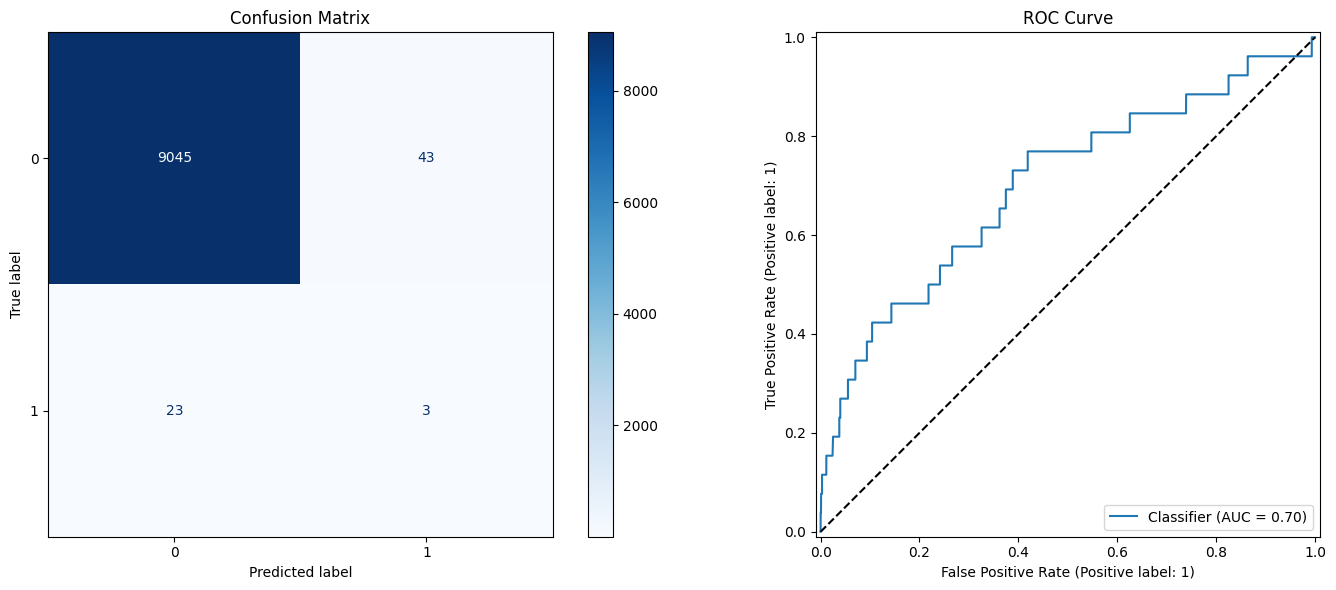

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Set up the figure with three subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# 2. Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax[1])
ax[1].set_title('ROC Curve')
ax[1].plot([0, 1], [0, 1], 'k--') # Diagonal line

plt.tight_layout()
plt.show()

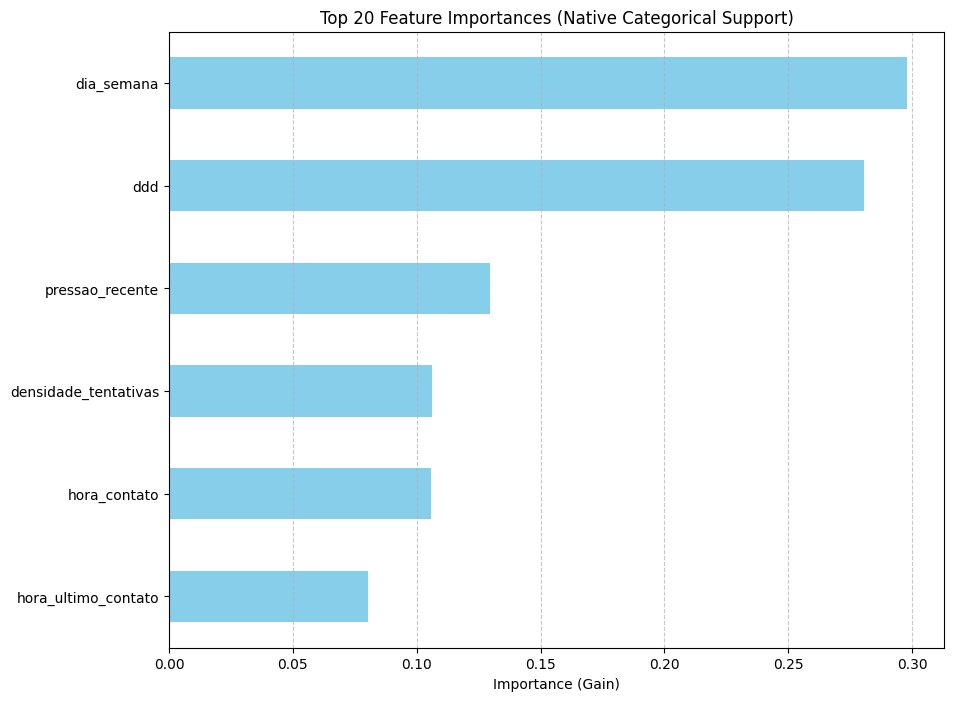

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate importance for the native categorical model
feature_names = X_train_encoded.columns.tolist()
importances = pd.Series(model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='skyblue')
plt.title('Top 20 Feature Importances (Native Categorical Support)')
plt.xlabel('Importance (Gain)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Calculando probabilidades médias por hora para toda a base de teste...

--- Melhores Horas para Contato (Média da Base de Teste) ---
 Hora Probabilidade_Media
   14             2.0957%
   12             0.9144%
   16             0.8311%
   13             0.7265%
   18             0.6592%
   17             0.6300%
   11             0.5868%
   15             0.5342%
    9             0.3992%
   10             0.3444%


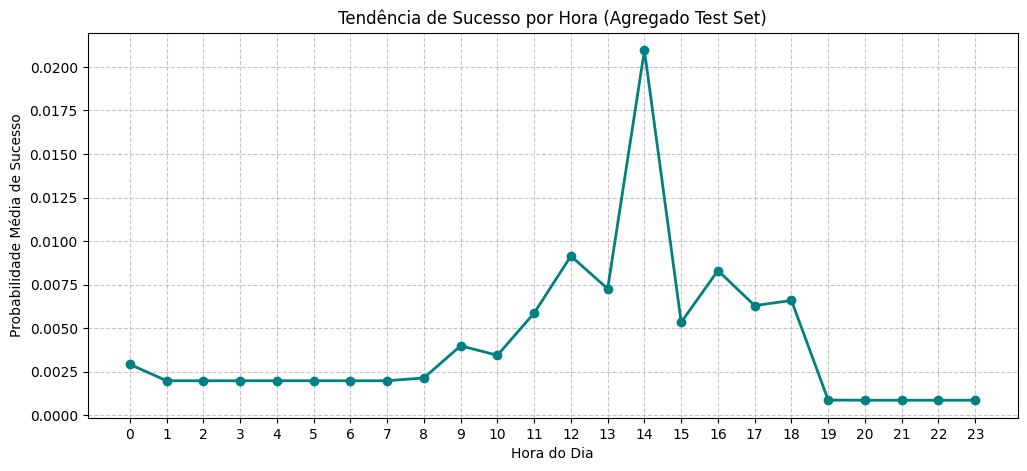

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Em vez de um único lead, vamos usar todos os leads do teste para ver a tendência geral
horas_testar = range(24)
medias_por_hora = []

print('Calculando probabilidades médias por hora para toda a base de teste...')

for h in horas_testar:
    X_sim = X_test_encoded.copy()
    X_sim['hora_contato'] = h
    # Garantir que o tipo de dado seja consistente com o treino
    X_sim['hora_contato'] = X_sim['hora_contato'].astype(X_train_encoded['hora_contato'].dtype)

    probs = model.predict_proba(X_sim)[:, 1]
    medias_por_hora.append({'Hora': h, 'Probabilidade_Media': np.mean(probs)})

df_otimizacao_global = pd.DataFrame(medias_por_hora)
df_otimizacao_global = df_otimizacao_global.sort_values(by='Probabilidade_Media', ascending=False)

print('\n--- Melhores Horas para Contato (Média da Base de Teste) ---')
# Aumentando a precisão decimal para capturar pequenas variações em dados desbalanceados
print(df_otimizacao_global.head(10).to_string(index=False, formatters={'Probabilidade_Media': '{:.4%}'.format}))

plt.figure(figsize=(12, 5))
plt.plot(range(24), [d['Probabilidade_Media'] for d in medias_por_hora], marker='o', color='teal', linewidth=2)
plt.xlabel('Hora do Dia')
plt.ylabel('Probabilidade Média de Sucesso')
plt.title('Tendência de Sucesso por Hora (Agregado Test Set)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Iniciando simulação para todo o dataset (excluindo 23h às 06h)...


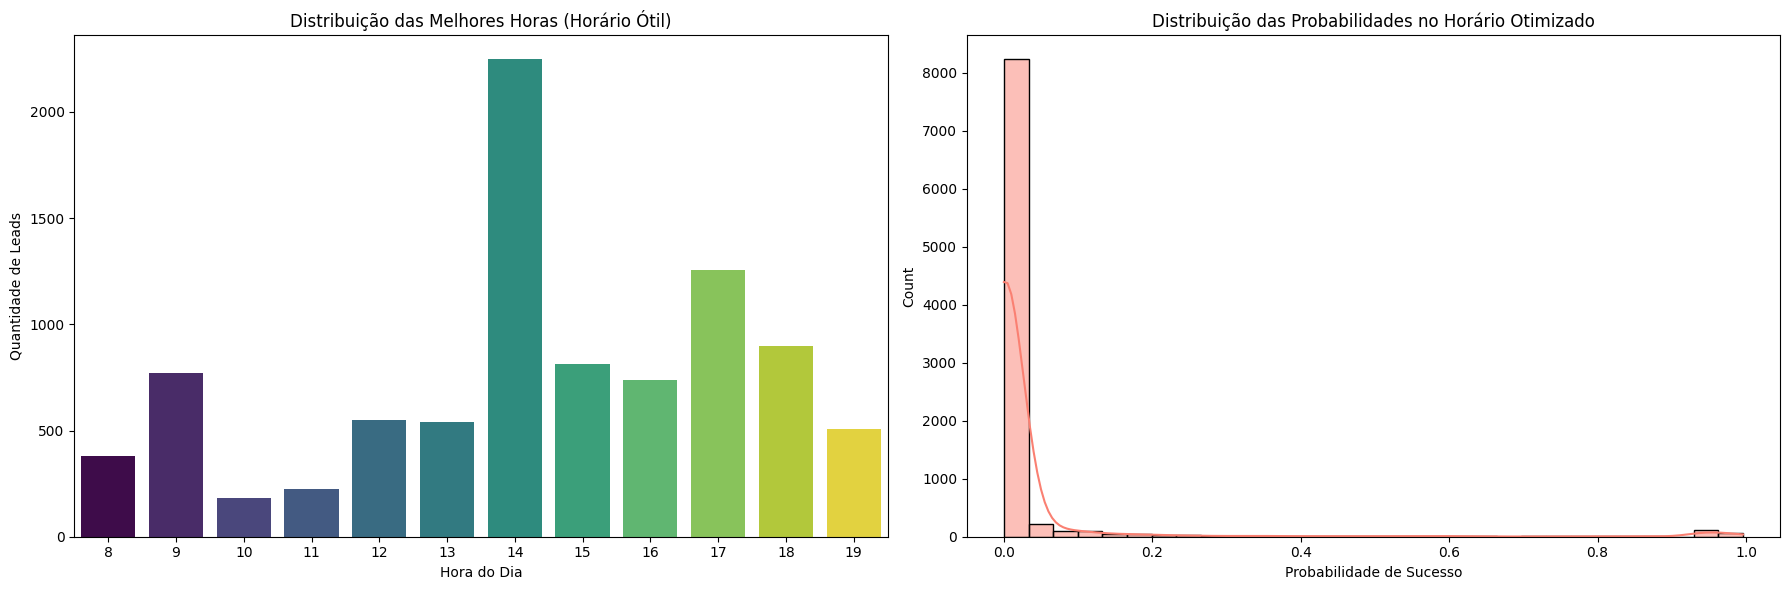


Resumo das recomendações (Horários Permitidos):
Melhor_Hora
8      380
9      773
10     184
11     226
12     548
13     539
14    2248
15     813
16     740
17    1257
18     898
19     508
Name: count, dtype: int64


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def prever_melhores_horarios(model, X_base):
    print('Iniciando simulação para todo o dataset (excluindo 23h às 06h)...')
    X_working = X_base.copy()

    # Lista para armazenar as probabilidades
    all_probs = []
    # Lista das horas válidas para predição
    horas_validas = [h for h in range(24) if not (h >= 23 or h <= 6)]

    for h in horas_validas:
        X_temp = X_working.copy()
        X_temp['hora_contato'] = h
        X_temp['hora_contato'] = X_temp['hora_contato'].astype(X_base['hora_contato'].dtype)

        # Predição de probabilidade para a hora 'h'
        probs = model.predict_proba(X_temp)[:, 1]
        all_probs.append(probs)

    # Converte para array. Shape: (len(horas_validas), n_leads)
    all_probs_array = np.array(all_probs)

    # Encontra o índice da melhor hora dentro da lista de horas válidas
    idx_best = np.argmax(all_probs_array, axis=0)
    best_hours = [horas_validas[i] for i in idx_best]
    max_probs = np.max(all_probs_array, axis=0)

    return np.array(best_hours), max_probs

# Executar predição no conjunto de teste completo
melhores_horas, prob_maximas = prever_melhores_horarios(model, X_test_encoded)

# Adicionar ao DataFrame de resultados para visualização
df_best = pd.DataFrame({
    'Melhor_Hora': melhores_horas,
    'Probabilidade': prob_maximas
})

# Plotagem dos Gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribuição das Melhores Horas Escolhidas
sns.countplot(x='Melhor_Hora', data=df_best, ax=ax[0], palette='viridis', hue='Melhor_Hora', legend=False)
ax[0].set_title('Distribuição das Melhores Horas (Horário Ótil)')
ax[0].set_xlabel('Hora do Dia')
ax[0].set_ylabel('Quantidade de Leads')

# 2. Distribuição das Probabilidades máximas alcançadas
sns.histplot(df_best['Probabilidade'], bins=30, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribuição das Probabilidades no Horário Otimizado')
ax[1].set_xlabel('Probabilidade de Sucesso')

plt.tight_layout()
plt.show()

print('\nResumo das recomendações (Horários Permitidos):')
print(df_best['Melhor_Hora'].value_counts().sort_index())

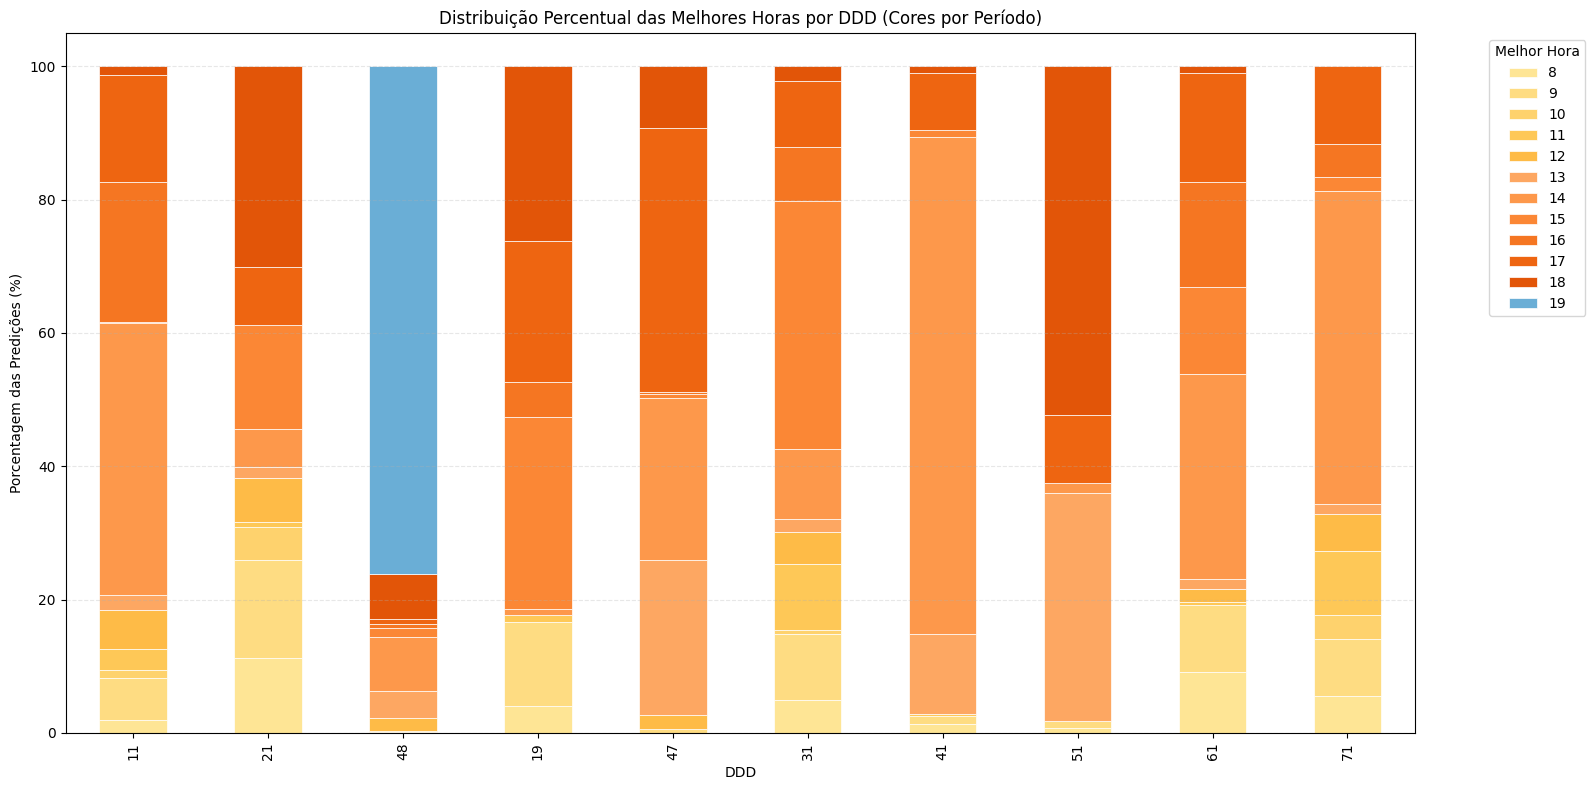

Tabela de Contingência (% dentro de cada DDD - Top 15):


Melhor_Hora,8,9,10,11,12,13,14,15,16,17,18,19
ddd,,,,,,,,,,,,
11,2.00%,6.22%,1.18%,3.25%,5.76%,2.29%,40.83%,0.04%,21.06%,16.05%,1.32%,0.00%
12,5.33%,4.00%,6.67%,0.00%,9.33%,4.00%,30.67%,13.33%,8.00%,14.67%,4.00%,0.00%
13,6.35%,4.76%,4.76%,3.17%,7.94%,1.59%,20.63%,14.29%,6.35%,23.81%,6.35%,0.00%
14,7.69%,13.46%,3.85%,26.92%,11.54%,13.46%,1.92%,7.69%,0.00%,1.92%,11.54%,0.00%
15,2.88%,6.73%,0.96%,2.88%,8.65%,10.58%,0.00%,0.00%,0.00%,0.00%,67.31%,0.00%
16,4.55%,15.15%,12.12%,0.00%,21.21%,6.06%,12.12%,9.09%,1.52%,16.67%,1.52%,0.00%
17,0.00%,2.38%,0.00%,0.00%,2.38%,19.05%,64.29%,0.00%,0.00%,0.00%,11.90%,0.00%
18,8.22%,13.70%,2.74%,2.74%,4.11%,13.70%,17.81%,10.96%,2.74%,23.29%,0.00%,0.00%
19,3.98%,12.69%,0.00%,1.07%,0.00%,0.00%,0.92%,28.75%,5.20%,21.25%,26.15%,0.00%


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Criando um DataFrame temporário com DDD e as Melhores Horas calculadas
df_ddd_dist = X_test_encoded[['ddd']].copy().reset_index(drop=True)
df_ddd_dist['Melhor_Hora'] = df_best['Melhor_Hora']

# 1. Tabela de Contingência normalizada por DDD (index)
pivot_table_pct_ddd = pd.crosstab(df_ddd_dist['ddd'], df_ddd_dist['Melhor_Hora'], normalize='index') * 100

# 2. Selecionando os 10 DDDs com mais leads para o gráfico
top_ddds = df_ddd_dist['ddd'].value_counts().head(10).index
df_plot_data = pivot_table_pct_ddd.loc[top_ddds]

# 3. Definição de cores personalizadas por período
# Manhã (7-12): Amarelos | Tarde (13-18): Laranjas | Noite (19-22): Azuis
def get_color_for_hour(hour):
    if 7 <= hour <= 12:
        return plt.cm.YlOrBr(np.linspace(0.2, 0.4, 6))[hour-7] # Tons de Amarelo/Ouro
    elif 13 <= hour <= 18:
        return plt.cm.Oranges(np.linspace(0.4, 0.7, 6))[hour-13] # Tons de Laranja
    else:
        return plt.cm.Blues(np.linspace(0.5, 0.9, 4))[min(hour-19, 3)] # Tons de Azul

# Criar a lista de cores baseada nas colunas (horas) presentes no df_plot_data
colors = [get_color_for_hour(int(h)) for h in df_plot_data.columns]

# 4. Gráfico de barras empilhadas com cores customizadas
ax = df_plot_data.plot(kind='bar', stacked=True, figsize=(16, 8), color=colors, edgecolor='white', linewidth=0.5)

plt.title('Distribuição Percentual das Melhores Horas por DDD (Cores por Período)')
plt.xlabel('DDD')
plt.ylabel('Porcentagem das Predições (%)')
plt.legend(title='Melhor Hora', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('Tabela de Contingência (% dentro de cada DDD - Top 15):')
display(pivot_table_pct_ddd.head(15).style.format('{:.2f}%'))

In [23]:
import pickle
from google.colab import files

# Nome do arquivo para o modelo
model_filename = 'xgboost_model_leads.pkl'

# Salvar o modelo usando pickle
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f'Modelo salvo com sucesso como {model_filename}')

# Iniciar o download no navegador
files.download(model_filename)

Modelo salvo com sucesso como xgboost_model_leads.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

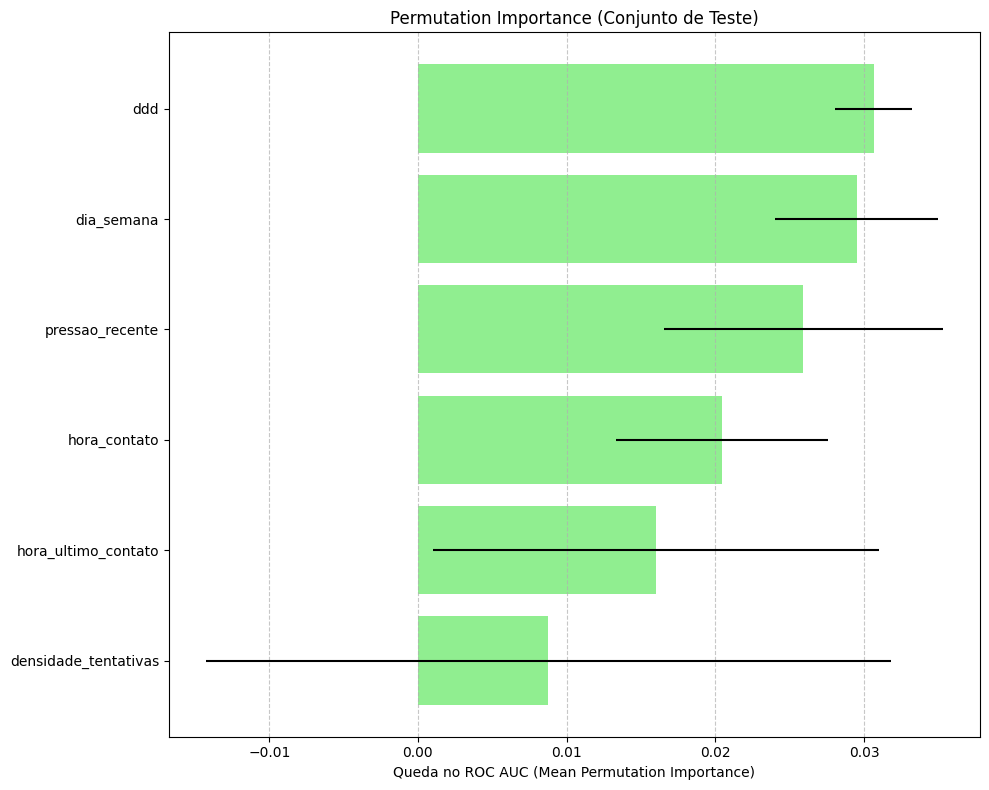

Ranking de Permutation Importance (Top 20):
             feature  importance_mean  importance_std
                 ddd         0.030650        0.002588
          dia_semana         0.029518        0.005482
     pressao_recente         0.025924        0.009401
        hora_contato         0.020445        0.007114
 hora_ultimo_contato         0.016008        0.014970
densidade_tentativas         0.008782        0.023047


In [24]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Realizando o clculo da Permutation Importance
# Usamos o conjunto de teste para avaliar a generalizao
# scoring='roc_auc'  adequado para este problema desbalanceado
r = permutation_importance(model, X_test_encoded, y_test,
                           n_repeats=10,
                           random_state=42,
                           n_jobs=-1,
                           scoring='average_precision')

# Organizando os resultados em um DataFrame
feature_names = X_test_encoded.columns
perm_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Plotando os resultados
plt.figure(figsize=(10, 8))
plt.barh(perm_imp_df['feature'], perm_imp_df['importance_mean'], xerr=perm_imp_df['importance_std'], color='lightgreen')
plt.xlabel('Queda no ROC AUC (Mean Permutation Importance)')
plt.title('Permutation Importance (Conjunto de Teste)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Ranking de Permutation Importance (Top 20):")
print(perm_imp_df.head(20).to_string(index=False))

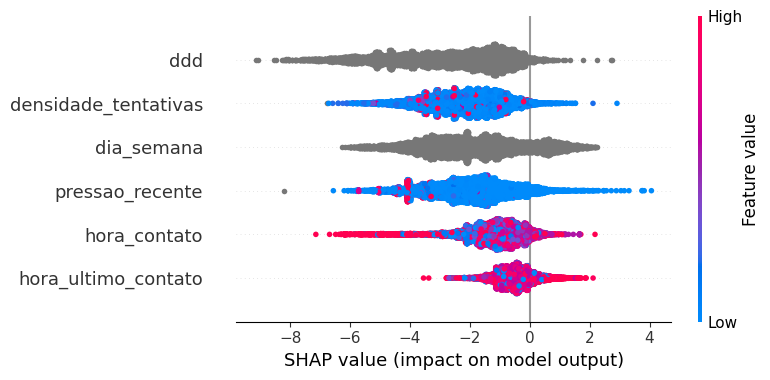

Interpretando o SHAP Summary Plot:
1. O eixo X (SHAP value) indica se a feature aumenta (>0) ou diminui (<0) a chance de conversão.
2. A cor (Vermelho = Alto, Azul = Baixo) indica o valor original da feature.
3. Exemplo: Se 'horas_desde_ultimo_contato' em azul estiver à direita, significa que valores baixos dessa feature aumentam a chance de sucesso.


In [25]:
import shap
import matplotlib.pyplot as plt

# Inicializar o explicador SHAP específico para modelos de árvore (TreeExplainer)
explainer = shap.TreeExplainer(model)

# Calcular os SHAP values para o conjunto de teste
# Nota: Usamos X_test_encoded pois o modelo foi treinado com categorias nativas
shap_values = explainer.shap_values(X_test_encoded)

# Gerar o Summary Plot
# Este gráfico mostra o impacto (SHAP value) de cada feature na saída do modelo
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_encoded, plot_type="dot")

print("Interpretando o SHAP Summary Plot:")
print("1. O eixo X (SHAP value) indica se a feature aumenta (>0) ou diminui (<0) a chance de conversão.")
print("2. A cor (Vermelho = Alto, Azul = Baixo) indica o valor original da feature.")
print("3. Exemplo: Se 'horas_desde_ultimo_contato' em azul estiver à direita, significa que valores baixos dessa feature aumentam a chance de sucesso.")

Simulando Lead índice 0. Início: Hora 14, Dia 3

--- Janela de Oportunidade (Excluindo 23h-06h) ---


,Horas_Frente,Hora_Relogio,Dia_Semana,Probabilidade
0,1,15,3,0.000308
1,2,16,3,0.000783
2,3,17,3,0.000134
3,4,18,3,0.000007
4,5,19,3,0.000000
5,6,20,3,0.000000
6,7,21,3,0.000000
7,8,22,3,0.000000
8,17,7,4,0.002070
9,18,8,4,0.002323


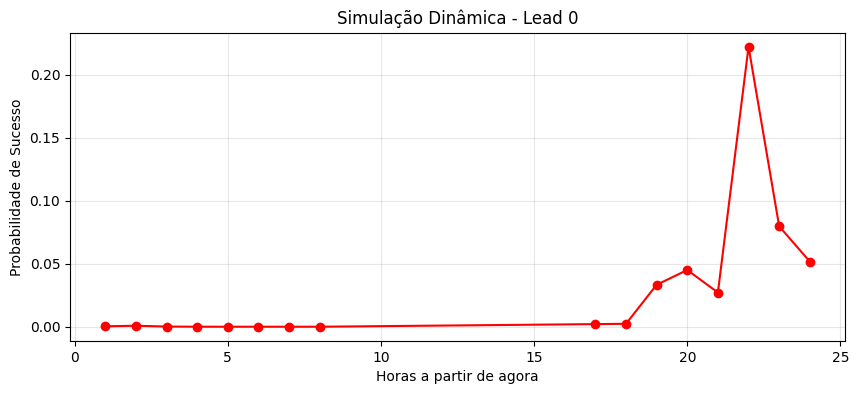

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO EDITÁVEL ---
indice_lead = 0  # Altere aqui para testar outros leads (0 a 9113)
# -----------------------------

# 1. Selecionando o lead da base de teste
lead_exemplo = X_test_encoded.iloc[indice_lead].copy()

# 2. Configurações da Simulação
horas_para_simular = 24
resultados_dinamicos = []

# Estado inicial do 'relógio'
hora_atual = int(lead_exemplo['hora_contato'])
dia_atual = int(lead_exemplo['dia_semana'])

print(f"Simulando Lead índice {indice_lead}. Início: Hora {hora_atual}, Dia {dia_atual}")

for i in range(1, horas_para_simular + 1):
    # Avançamos o relógio
    tempo_total_passado = i
    proxima_hora = (hora_atual + tempo_total_passado) % 24
    novo_dia_semana = (dia_atual + ((hora_atual + tempo_total_passado) // 24)) % 7

    # REGRA: Pular horários entre 23h e 06h
    if proxima_hora >= 23 or proxima_hora <= 6:
        continue

    # Criamos o cenário dinâmico
    cenario = lead_exemplo.copy()
    cenario['hora_contato'] = proxima_hora
    cenario['dia_semana'] = novo_dia_semana

    # Nota: Removidas atualizações de 'horas_desde_...' pois não existem no CSV atual

    # Preparar DataFrame para o modelo
    df_sim = pd.DataFrame([cenario])
    for col in ['ddd', 'dia_semana']:
        df_sim[col] = df_sim[col].astype('category').cat.set_categories(X_train_encoded[col].cat.categories)

    prob = model.predict_proba(df_sim)[0][1]

    resultados_dinamicos.append({
        'Horas_Frente': i,
        'Hora_Relogio': proxima_hora,
        'Dia_Semana': novo_dia_semana,
        'Probabilidade': prob
    })

# 3. Exibindo os resultados
if resultados_dinamicos:
    df_simulacao = pd.DataFrame(resultados_dinamicos)
    print(f"\n--- Janela de Oportunidade (Excluindo 23h-06h) ---")
    display(df_simulacao.style.highlight_max(subset=['Probabilidade'], color='lightgreen'))

    plt.figure(figsize=(10, 4))
    plt.plot(df_simulacao['Horas_Frente'], df_simulacao['Probabilidade'], marker='o', color='red')
    plt.title(f'Simulação Dinâmica - Lead {indice_lead}')
    plt.xlabel('Horas a partir de agora')
    plt.ylabel('Probabilidade de Sucesso')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Nenhum horário válido encontrado na janela de 24h.")

### 🧪 Teste de Lead Customizado
Defina os valores abaixo para criar um perfil de lead do zero e ver a previsão do modelo.

Previsão para Lead Customizado (Início: 10h, Dia 5)


,Hora,Dia,Probabilidade
0,11,5,0.000040
1,12,5,0.000035
2,13,5,0.000084
3,14,5,0.000202
4,15,5,0.000222
5,16,5,0.000308
6,17,5,0.001222
7,18,5,0.000570
8,19,5,0.000582
9,20,5,0.000582


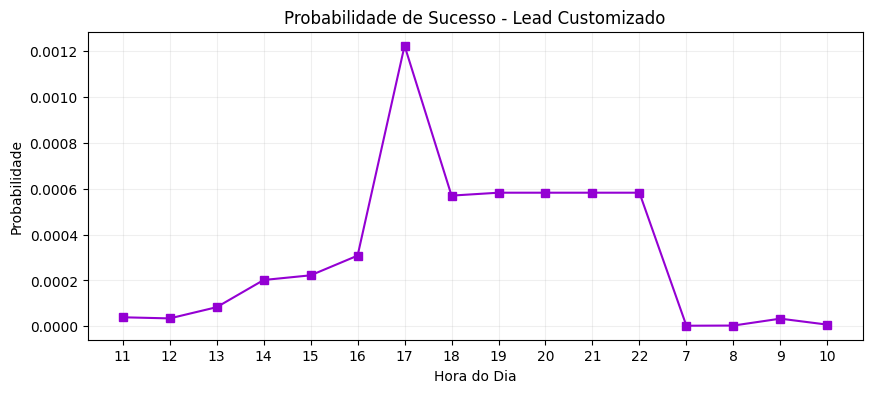

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DEFINA SEU LEAD AQUI ---
# Ajustado para conter apenas as features que o modelo conhece
custom_lead_data = {
    'ddd': '48',              # String
    'hora_contato': 10,       # Inteiro (0-23)
    'dia_semana': 5,          # Inteiro (0=Segunda, 6=Domingo)
    'hora_ultimo_contato': 14.0,
    'densidade_tentativas': 0.34,
    'pressao_recente': 5.5
}
# ----------------------------

# 1. Preparar o DataFrame base
lead_custom = pd.Series(custom_lead_data)

# 2. Simulação de 24 horas
horas_para_simular = 24
resultados_custom = []

for i in range(1, horas_para_simular + 1):
    tempo_passado = i
    proxima_hora = (int(lead_custom['hora_contato']) + tempo_passado) % 24
    novo_dia = (int(lead_custom['dia_semana']) + ((int(lead_custom['hora_contato']) + tempo_passado) // 24)) % 7

    if proxima_hora >= 23 or proxima_hora <= 6: continue

    cenario = lead_custom.copy()
    cenario['hora_contato'] = proxima_hora
    cenario['dia_semana'] = novo_dia
    # Nota: Removidas atualizações de colunas extras que causavam o erro de mismatch

    df_sim = pd.DataFrame([cenario])

    # Garantir dtypes categóricos iguais ao treino
    for col in ['ddd', 'dia_semana']:
        df_sim[col] = df_sim[col].astype(str).astype('category').cat.set_categories(X_train_encoded[col].cat.categories)

    prob = model.predict_proba(df_sim)[0][1]
    resultados_custom.append({'Hora': proxima_hora, 'Dia': novo_dia, 'Probabilidade': prob})

# 3. Visualização
if resultados_custom:
    df_res = pd.DataFrame(resultados_custom)
    print(f"Previsão para Lead Customizado (Início: {custom_lead_data['hora_contato']}h, Dia {custom_lead_data['dia_semana']})")
    display(df_res.style.highlight_max(subset=['Probabilidade'], color='lightyellow'))

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(df_res)), df_res['Probabilidade'], marker='s', color='darkviolet')
    plt.xticks(range(len(df_res)), df_res['Hora'])
    plt.title('Probabilidade de Sucesso - Lead Customizado')
    plt.xlabel('Hora do Dia')
    plt.ylabel('Probabilidade')
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print('Ajuste o horário inicial para ver a janela operacional.')

### 📈 Análise de Elasticidade Temporal
Identificando quais features causam maior impacto na variação da probabilidade ao longo do dia.

Iniciando simulação de elasticidade para 1000 leads...


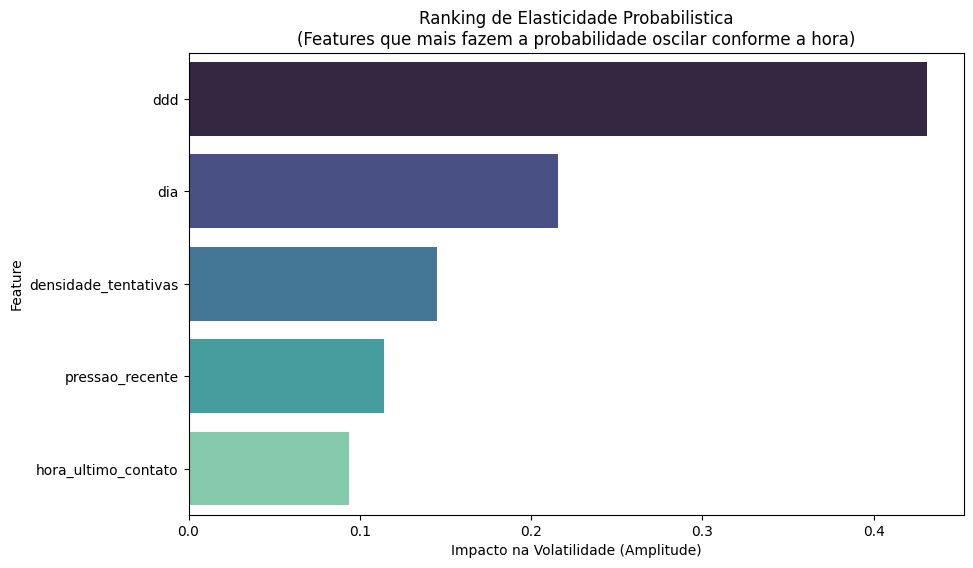

,Feature,Importancia_Elasticidade
0,ddd,0.430918
1,dia,0.215885
2,densidade_tentativas,0.145275
3,pressao_recente,0.114244
4,hora_ultimo_contato,0.093677


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# 1. Seleção da amostra (1000 leads)
n_amostra = 1000
X_amostra = X_test_encoded.head(n_amostra).copy()

# Lista para armazenar as amplitudes (nossa nova variável alvo)
amplitudes = []

print(f"Iniciando simulação de elasticidade para {n_amostra} leads...")

# 2 & 3. Simulação de 24 horas por lead
# Nota: Usamos o modelo 'model' que já está treinado no kernel
for idx in range(len(X_amostra)):
    lead_base = X_amostra.iloc[idx].copy()
    probs_simuladas = []

    # Criamos um mini-batch para todas as horas para acelerar a predição
    scenarios = []
    for h in range(24):
        cenario = lead_base.copy()
        cenario['hora_contato'] = h
        scenarios.append(cenario)

    df_batch = pd.DataFrame(scenarios)

    # Garantir dtypes categóricos consistentes com o treinamento do XGBoost
    for col in ['ddd', 'dia_semana']:
        df_batch[col] = df_batch[col].astype('category').cat.set_categories(X_train_encoded[col].cat.categories)

    # Predição em lote para as 24 horas
    probs = model.predict_proba(df_batch)[:, 1]

    # 4. Cálculo da Amplitude (Elasticidade)
    amplitude = np.max(probs) - np.min(probs)
    amplitudes.append(amplitude)

# 5. Criação do novo dataset de Volatilidade
X_vol = X_amostra.drop(columns=['hora_contato']).copy()
y_vol = np.array(amplitudes)

# 6. One-Hot Encoding para o Random Forest (que não aceita dtypes category diretamente)
X_vol_encoded = pd.get_dummies(X_vol, columns=['ddd', 'dia_semana'], drop_first=True)

# 7. Treino do RandomForestRegressor
rf_elasticidade = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_elasticidade.fit(X_vol_encoded, y_vol)

# 8. Extração e Ranking de Importância
# Como o One-Hot gera muitas colunas (DDD), vamos agrupar a importância para as features originais
importances = rf_elasticidade.feature_importances_
feature_names = X_vol_encoded.columns

# Mapeamento para agrupar dummies de volta às originais
raw_importances = {}
for name, imp in zip(feature_names, importances):
    origin = name.split('_')[0] if ('ddd_' in name or 'dia_semana_' in name) else name
    raw_importances[origin] = raw_importances.get(origin, 0) + imp

ranking_elasticidade = pd.DataFrame({
    'Feature': list(raw_importances.keys()),
    'Importancia_Elasticidade': list(raw_importances.values())
}).sort_values(by='Importancia_Elasticidade', ascending=False)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia_Elasticidade', y='Feature', data=ranking_elasticidade, palette='mako')
plt.title('Ranking de Elasticidade Probabilistica\n(Features que mais fazem a probabilidade oscilar conforme a hora)')
plt.xlabel('Impacto na Volatilidade (Amplitude)')
plt.show()

display(ranking_elasticidade.reset_index(drop=True))

### 📊 Avaliação Detalhada do Modelo
Relatório completo de métricas e curvas de performance no conjunto de teste.

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9088
           1       0.07      0.12      0.08        26

    accuracy                           0.99      9114
   macro avg       0.53      0.56      0.54      9114
weighted avg       0.99      0.99      0.99      9114



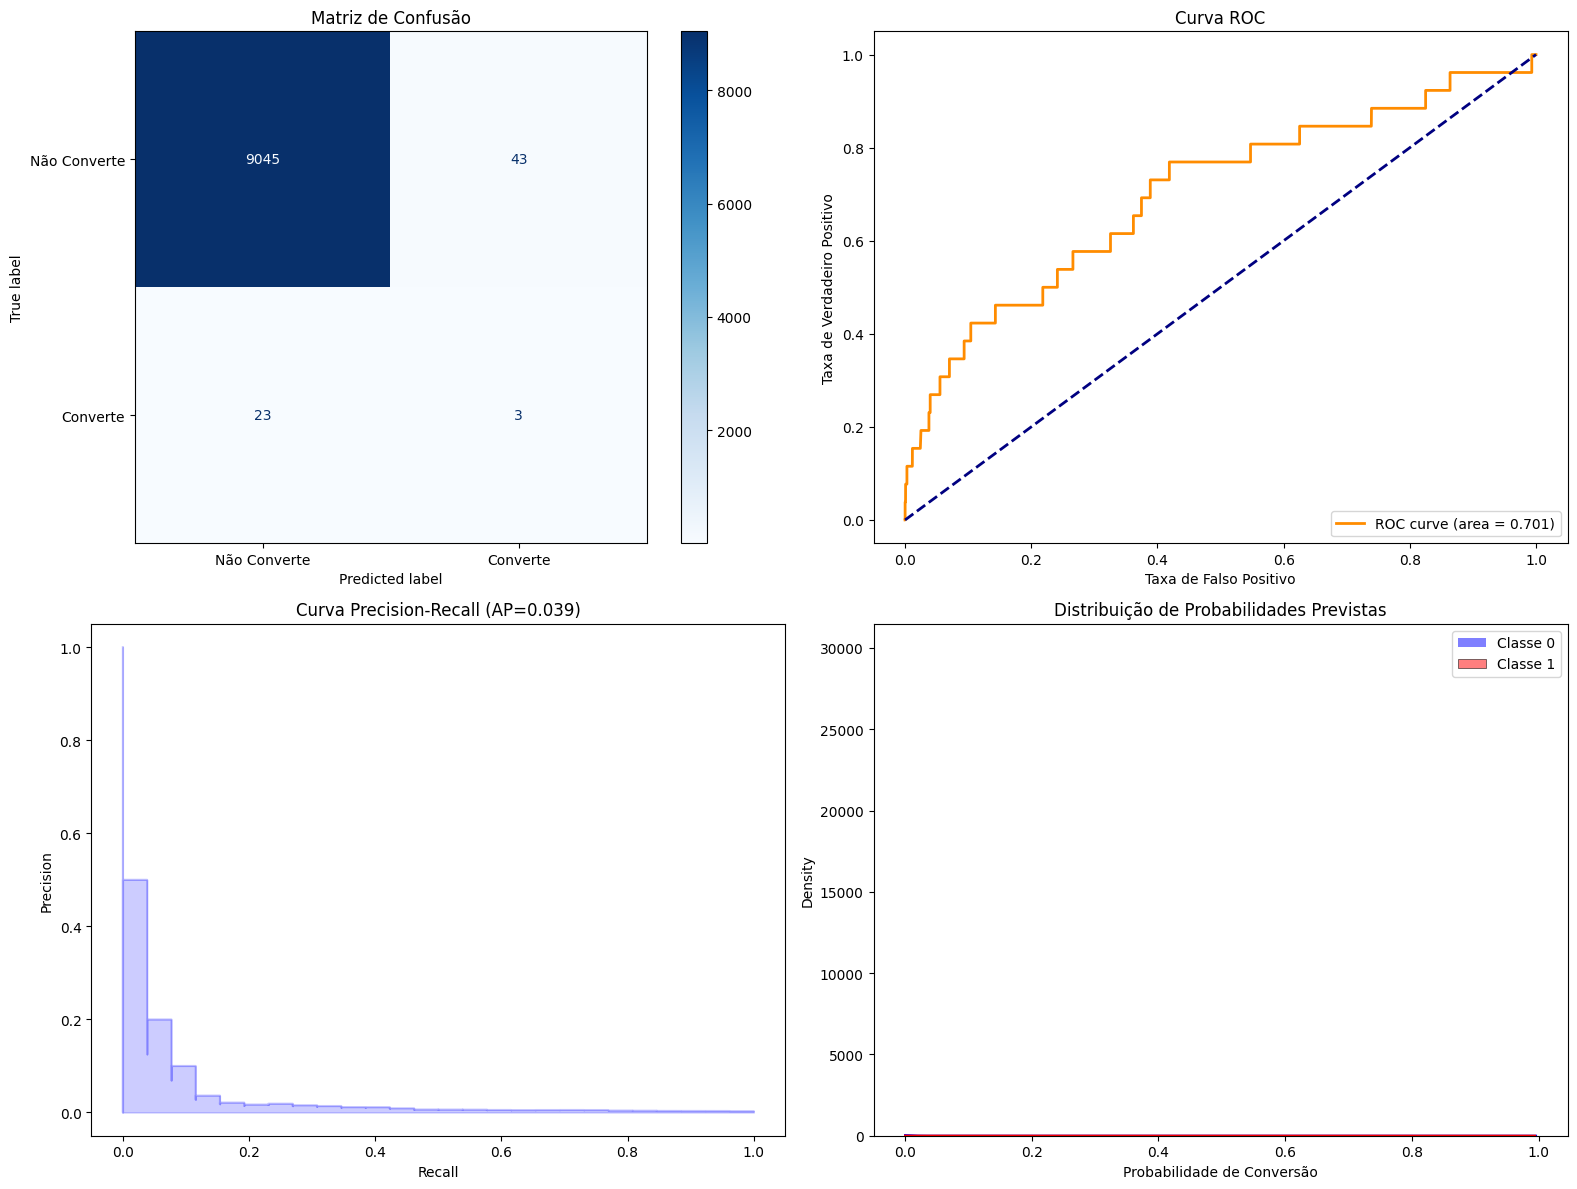

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Classification Report (Precisão, Recall, F1 por classe)
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 2. Matriz de Confusão e Curvas de Performance
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# A. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Converte', 'Converte'])
disp.plot(cmap='Blues', ax=ax[0, 0])
ax[0, 0].set_title('Matriz de Confusão')

# B. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
ax[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
ax[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0, 1].set_xlabel('Taxa de Falso Positivo')
ax[0, 1].set_ylabel('Taxa de Verdadeiro Positivo')
ax[0, 1].set_title('Curva ROC')
ax[0, 1].legend(loc="lower right")

# C. Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
ax[1, 0].step(recall, precision, color='b', alpha=0.2, where='post')
ax[1, 0].fill_between(recall, precision, step='post', alpha=0.2, color='b')
ax[1, 0].set_xlabel('Recall')
ax[1, 0].set_ylabel('Precision')
ax[1, 0].set_title(f'Curva Precision-Recall (AP={avg_prec:.3f})')

# D. Distribuição de Probabilidades
sns.histplot(y_pred_proba[y_test == 0], label='Classe 0', ax=ax[1, 1], color='blue', kde=True, stat="density", alpha=0.5)
sns.histplot(y_pred_proba[y_test == 1], label='Classe 1', ax=ax[1, 1], color='red', kde=True, stat="density", alpha=0.5)
ax[1, 1].set_title('Distribuição de Probabilidades Previstas')
ax[1, 1].set_xlabel('Probabilidade de Conversão')
ax[1, 1].legend()

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

# Função para listar as categorias conhecidas pelo modelo
def print_categories(df, title):
    print(f"\n=== {title} ===")
    categorical_cols = df.select_dtypes(include="category").columns
    if len(categorical_cols) == 0:
        print("Nenhuma coluna do tipo 'category' encontrada.")
    for col in categorical_cols:
        print(f"'{col}': {list(df[col].cat.categories)},")

# Usando o dataframe de treino codificado que foi usado no fit()
print_categories(X_train_encoded, "CATEGORIAS DE TREINAMENTO")


=== CATEGORIAS DE TREINAMENTO ===
'ddd': ['11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '24', '27', '28', '29', '31', '32', '33', '34', '35', '37', '38', '41', '42', '43', '44', '45', '46', '47', '48', '49', '51', '53', '54', '59', '61', '62', '63', '64', '65', '66', '67', '68', '69', '71', '73', '74', '75', '77', '79', '81', '82', '83', '84', '85', '86', '87', '88', '89', '91', '92', '94', '95', '97', '98', '99', 'na'],
'dia_semana': [0, 1, 2, 3, 4, 5, 6],


In [31]:
# Verificando o tipo dos elementos nas categorias de 'dia_semana'
dia_semana_categories = X_train_encoded['dia_semana'].cat.categories
print(f"Categorias em 'dia_semana': {list(dia_semana_categories)}")
print(f"Tipo dos elementos: {dia_semana_categories.dtype}")

# Exemplo de como preparar para produção
print("\nExemplo de código para produção:")
print("df_prod['dia_semana'] = df_prod['dia_semana'].astype(int).astype('category')")

Categorias em 'dia_semana': [0, 1, 2, 3, 4, 5, 6]
Tipo dos elementos: int64

Exemplo de código para produção:
df_prod['dia_semana'] = df_prod['dia_semana'].astype(int).astype('category')
